# Atividade 001 — Pipeline de Classificação com Seaborn

## Definição do problema

O dataset escolhido foi `penguins`, disponível na biblioteca Seaborn.

A variável alvo será `species`, ou seja, o objetivo do modelo será prever a espécie de um pinguim com base em características físicas e categóricas presentes no conjunto de dados.

Esse é um problema de classificação multiclasse, pois existem mais de duas categorias possíveis para a variável alvo.

## Justificativa
O objetivo é prever a espécie do pinguim com base em características físicas e variáveis categóricas.
Esse dataset é adequado porque contém variáveis numéricas e categóricas, além de valores ausentes, o que permite construir um pipeline completo com imputação, codificação e avaliação.

---

## Importação das bibliotecas

Nesta etapa são importadas as bibliotecas que serão utilizadas ao longo do projeto, incluindo ferramentas para manipulação de dados, visualização, pré-processamento, modelagem e avaliação dos resultados.

In [2]:
#IMPORTS DO PROJETO

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

---

## Carregamento do dataset

Nesta seção o conjunto de dados é carregado a partir da biblioteca Seaborn.
Em seguida, são exibidas as primeiras linhas da base para uma inspeção inicial da estrutura dos dados.

In [3]:
#CARREGANDO DATASET

df = sns.load_dataset("penguins")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


---

## Diagnóstico inicial dos dados

Antes de treinar os modelos, é necessário compreender a estrutura do dataset.
Nesta etapa serão analisados o número de linhas e colunas, os tipos de dados, a existência de valores ausentes e a distribuição das classes da variável alvo.

Shape: (344, 7)

Tipos das colunas:
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

Missing values por coluna:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


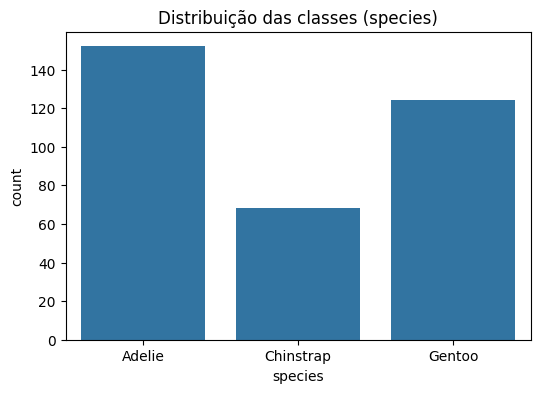

In [4]:
#DIAGNOSTICO RELACIONADO AO TAMANHO DO DATASET

print("Shape:", df.shape)
print("\nTipos das colunas:")
print(df.dtypes)

print("\nMissing values por coluna:")
print(df.isna().sum())

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="species")
plt.title("Distribuição das classes (species)")
plt.show()

---

## Definição de X e y

Nesta etapa são separadas as variáveis preditoras e a variável alvo.
As colunas escolhidas para `X` representarão as características de entrada do modelo, enquanto `y` conterá a classe que se deseja prever.

In [5]:
#DEFININDO X & y

target = "species"
features = ["island", "bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g", "sex"]

X = df[features]
y = df[target]

---

## Separação entre treino e teste

Nesta etapa o conjunto de dados é dividido em treino e teste.
O conjunto de treino será utilizado para ajustar os modelos, enquanto o conjunto de teste servirá para avaliar sua capacidade de generalização em dados não vistos.

In [6]:
#SEPARANDO TREINO DO TESTE

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape, y_train.shape)
print("Teste :", X_test.shape, y_test.shape)

Treino: (275, 6) (275,)
Teste : (69, 6) (69,)


---

## Pré-processamento dos dados

Os dados brutos geralmente não podem ser enviados diretamente aos modelos de machine learning.
Por isso, nesta etapa será construído um pipeline de pré-processamento para tratar valores ausentes, padronizar variáveis numéricas e transformar variáveis categóricas em representação numérica.

In [7]:
#PRÉ-PROCESSAMENTO DO DADOS

numeric_features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
categorical_features = ["island", "sex"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

---

## Modelo baseline

Nesta etapa será treinado um modelo baseline, ou seja, um modelo inicial e mais simples que servirá como referência para comparação.
O objetivo é observar o desempenho de uma abordagem básica antes de testar um modelo potencialmente mais poderoso.

In [8]:
#BASELINE

baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

---

## Avaliação do baseline

O modelo baseline será avaliado com dados de teste para medir seu desempenho em exemplos não utilizados durante o treinamento.
Serão utilizadas métricas como acurácia, classification report e matriz de confusão.

In [9]:
#AVALIAÇÃO DA BASELINE

print("----> BASELINE: Logistic Regression <----")
print("Accuracy:", accuracy_score(y_test, y_pred_baseline))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))


----> BASELINE: Logistic Regression <----
Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



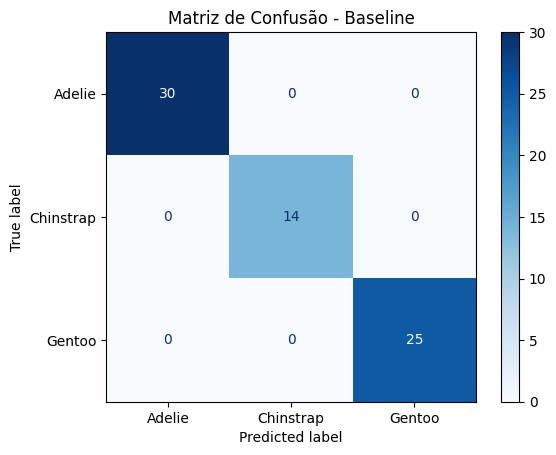

In [10]:
cm_baseline = confusion_matrix(y_test, y_pred_baseline, labels=baseline_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_baseline, display_labels=baseline_model.classes_)
disp.plot(cmap="Blues")
plt.title("Matriz de Confusão - Baseline")
plt.show()

---

## Modelo melhorado

Após o baseline, será treinado um segundo modelo com o objetivo de obter melhor desempenho.
A proposta é comparar os resultados entre uma abordagem inicial e outra potencialmente mais robusta.

In [11]:
#MELHORADO

improved_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42
    ))
])

improved_model.fit(X_train, y_train)
y_pred_improved = improved_model.predict(X_test)

---

## Avaliação do modelo melhorado

Assim como no baseline, o segundo modelo será avaliado com o conjunto de teste.
O objetivo é verificar se houve ganho de desempenho em relação ao modelo inicial, utilizando as mesmas métricas de avaliação.

In [12]:
#AVALIAÇÃO MODELO MELHORADO

print("----> MELHORIA: Random Forest <----")
print("Accuracy:", accuracy_score(y_test, y_pred_improved))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_improved))

----> MELHORIA: Random Forest <----
Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



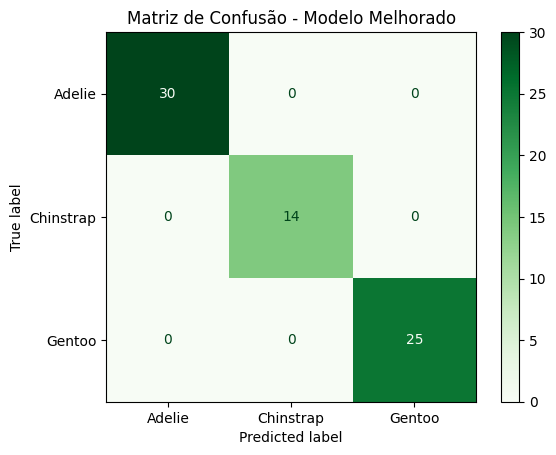

In [13]:
cm_improved = confusion_matrix(y_test, y_pred_improved, labels=improved_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_improved, display_labels=improved_model.classes_)
disp.plot(cmap="Greens")
plt.title("Matriz de Confusão - Modelo Melhorado")
plt.show()

---

## Comparação entre os modelos

Nesta etapa será feita uma comparação direta entre os dois modelos treinados.
A análise considerará principalmente a acurácia e o comportamento de cada modelo nas diferentes classes, permitindo identificar qual abordagem apresentou melhor desempenho.

In [14]:
#COMPARAÇÃO ENTRE MODELOS

acc_baseline = accuracy_score(y_test, y_pred_baseline)
acc_improved = accuracy_score(y_test, y_pred_improved)

comparison = pd.DataFrame({
    "Modelo": ["Logistic Regression", "Random Forest"],
    "Accuracy": [acc_baseline, acc_improved]
})

comparison

,Modelo,Accuracy
0,Logistic Regression,1.0
1,Random Forest,1.0


---


## Interpretação humana dos erros

Neste problema, errar significa dizer que um pinguim pertence a uma espécie quando, na verdade, ele é de outra.

Por exemplo, se o modelo diz que o pinguim é Adelie, mas o correto era Chinstrap, isso mostra que, pelas informações usadas no treinamento, essas duas espécies pareceram parecidas o bastante para gerar confusão.

No modelo baseline, esse tipo de erro costuma acontecer mais porque ele é mais simples e tem mais dificuldade para separar casos parecidos. Já o Random Forest, por ser um modelo mais robusto, tende a identificar melhor essas diferenças e, por isso, normalmente erra menos.

Para descobrir em qual espécie o modelo mais se confunde, basta olhar a matriz de confusão e o recall no relatório de classificação. A espécie com menor recall é aquela em que o modelo mais deixou de acertar exemplos que realmente pertenciam a ela.